In [1]:
pip install numpy pandas matplotlib yfinance


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install keras


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [5]:
start='2015-01-01'
end='2025-12-31'
stock='GOOG'

data=yf.download(stock,start,end)

[*********************100%***********************]  1 of 1 completed


In [6]:
data

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
2015-01-02,25.955559,26.275053,25.920445,26.163278,28951268
2015-01-05,25.414503,25.931824,25.374444,25.878904,41196796
2015-01-06,24.825468,25.528501,24.780464,25.470389,57998800
2015-01-07,24.782936,25.086800,24.711223,25.074732,41301082
2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641
...,...,...,...,...,...
2025-12-23,315.457764,316.077322,310.531242,310.915980,13961400
2025-12-24,315.447784,316.067343,313.099433,315.927427,6138200
2025-12-26,314.738251,316.337130,313.499133,315.697597,6730900


In [7]:
data.columns = [f"{col[0]} {col[1]}" for col in data.columns]

data.rename(columns={
    "Price Ticker":"Date",
    "Close GOOG":"Close",
    "High GOOG":"High",
    "Low GOOG":"Low",
    "Open GOOG":"Open",
    "Volume GOOG":"Volume"
},inplace=True)

In [8]:
data

,Close,High,Low,Open,Volume
2015-01-02,25.955559,26.275053,25.920445,26.163278,28951268
2015-01-05,25.414503,25.931824,25.374444,25.878904,41196796
2015-01-06,24.825468,25.528501,24.780464,25.470389,57998800
2015-01-07,24.782936,25.086800,24.711223,25.074732,41301082
2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641
...,...,...,...,...,...
2025-12-23,315.457764,316.077322,310.531242,310.915980,13961400
2025-12-24,315.447784,316.067343,313.099433,315.927427,6138200
2025-12-26,314.738251,316.337130,313.499133,315.697597,6730900
2025-12-29,314.168701,314.748279,311.680433,312.599799,12317700


In [9]:
data.index.name = "Date"

In [10]:
data.reset_index(inplace=True)

In [11]:
data

,Date,Close,High,Low,Open,Volume
0,2015-01-02,25.955559,26.275053,25.920445,26.163278,28951268
1,2015-01-05,25.414503,25.931824,25.374444,25.878904,41196796
2,2015-01-06,24.825468,25.528501,24.780464,25.470389,57998800
3,2015-01-07,24.782936,25.086800,24.711223,25.074732,41301082
4,2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641
...,...,...,...,...,...,...
2760,2025-12-23,315.457764,316.077322,310.531242,310.915980,13961400
2761,2025-12-24,315.447784,316.067343,313.099433,315.927427,6138200
2762,2025-12-26,314.738251,316.337130,313.499133,315.697597,6730900
2763,2025-12-29,314.168701,314.748279,311.680433,312.599799,12317700


In [12]:
data.shape

(2765, 6)

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2765 entries, 0 to 2764
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    2765 non-null   datetime64[s]
 1   Close   2765 non-null   float64      
 2   High    2765 non-null   float64      
 3   Low     2765 non-null   float64      
 4   Open    2765 non-null   float64      
 5   Volume  2765 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 129.7 KB


In [14]:
ma_100_days=data['Close'].rolling(100).mean()

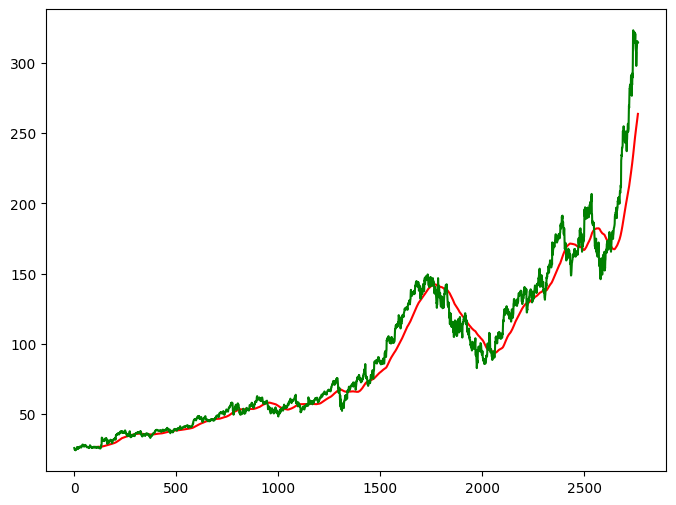

In [15]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days,'r')
plt.plot(data['Close'],'g')

plt.show()

In [16]:
ma_200_days=data['Close'].rolling(200).mean()

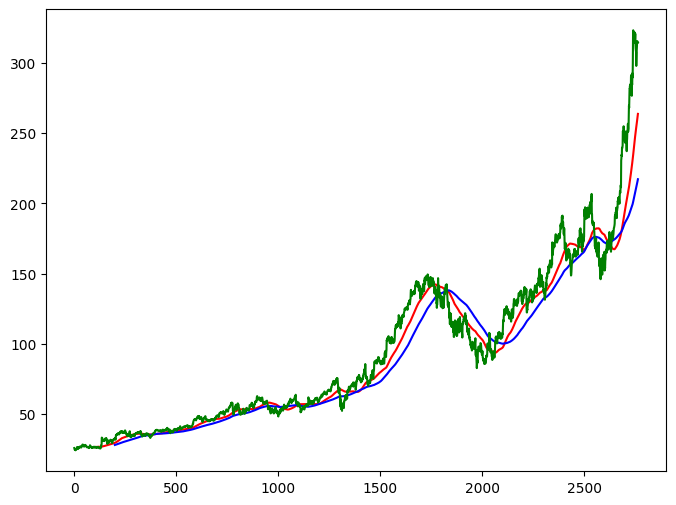

In [17]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days,'r')
plt.plot(ma_200_days,'b')
plt.plot(data['Close'],'g')

plt.show()

In [18]:
data.dropna(inplace=True)

In [19]:
data_train = pd.DataFrame(data['Close'][0:int(len(data)*0.80)])
data_test = pd.DataFrame(data['Close'][int(len(data)*0.80):len(data)])

In [20]:
data_train.shape[0]

2212

In [21]:
data_test.shape[0]

553

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [23]:
data_train_scale=scaler.fit_transform(data_train)

In [24]:
x=[]
y=[]
for i in range(100,data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [25]:
from keras.layers import Dense,Dropout,LSTM
from keras.models import Sequential

In [26]:
x=np.array(x)
y=np.array(y)

In [27]:
model=Sequential()

model.add(LSTM(units=50,activation='relu',return_sequences=True,input_shape=((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units=80,activation='relu',return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=100,activation='relu',return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=120,activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(units=1))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [29]:
model.fit(x,y,epochs=50,batch_size=32,verbose=1)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 0.0319
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0067
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0058
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0055
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0056
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0050
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0056
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0044
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0047
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0043
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0039
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0038
Epoch 13/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 0.0039
Epoch 14/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0036
Epoch 15/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0035
Epoc

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 80)        │        41,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 100)       │        72,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │       106,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 692,765 (2.64 MB)

 Trainable params: 230,921 (902.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 461,844 (1.76 MB)

In [31]:
from keras.layers import GRU

model1 = Sequential()

model1.add(GRU(units=60, return_sequences=True, input_shape=(x.shape[1], 1)))
model1.add(Dropout(0.2))

model1.add(GRU(units=80, return_sequences=True))
model1.add(Dropout(0.2))

model1.add(GRU(units=100, return_sequences=True))
model1.add(Dropout(0.2))

model1.add(GRU(units=120))
model1.add(Dropout(0.2))

model1.add(Dense(units=1))

In [32]:
model1.compile(optimizer='adam',loss='mean_squared_error')

In [33]:
model1.fit(x,y,epochs=60,batch_size=32,verbose=1)

Epoch 1/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0141
Epoch 2/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0021
Epoch 3/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0021
Epoch 4/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0019
Epoch 5/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0016
Epoch 6/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0018
Epoch 7/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0015
Epoch 8/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0016
Epoch 9/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0013
Epoch 10/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0016
Epoch 11/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0015
Epoch 12/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0015
Epoch 13/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0017
Epoch 14/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0014
Epoch 15/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0015
Epoc

In [34]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 100, 60)        │        11,340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 100, 80)        │        34,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 100, 100)       │        54,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 120)            │        79,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 540,185 (2.06 MB)

 Trainable params: 180,061 (703.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 360,124 (1.37 MB)

In [35]:
past_100_days=data_train.tail(100)

In [36]:
data_test=pd.concat((past_100_days,data_test),ignore_index=True)

In [37]:
data_test

,Close
0,120.649475
1,123.337402
2,124.408615
3,123.625053
4,122.365395
...,...
648,315.457764
649,315.447784
650,314.738251
651,314.168701


In [38]:
data_test_scale = scaler.transform(data_test)

In [39]:
x=[]
y=[]
for i in range(100,data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])

In [40]:
x,y = np.array(x),np.array(y)

In [41]:
y_predict1 = model.predict(x)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [42]:
y_predict1

array([[0.8469411 ],
       [0.8504075 ],
       [0.8529382 ],
       [0.8544338 ],
       [0.85457397],
       [0.8536314 ],
       [0.8523741 ],
       [0.84922373],
       [0.8432865 ],
       [0.8345802 ],
       [0.8239683 ],
       [0.8124913 ],
       [0.80141765],
       [0.79188025],
       [0.78472066],
       [0.7804688 ],
       [0.7793596 ],
       [0.7811444 ],
       [0.7848544 ],
       [0.7898166 ],
       [0.79528546],
       [0.8009238 ],
       [0.806563  ],
       [0.812346  ],
       [0.8179008 ],
       [0.8230498 ],
       [0.8277589 ],
       [0.83220124],
       [0.8360646 ],
       [0.8390993 ],
       [0.8413464 ],
       [0.84250927],
       [0.842152  ],
       [0.8402333 ],
       [0.8366662 ],
       [0.832026  ],
       [0.8268243 ],
       [0.82238114],
       [0.8194802 ],
       [0.8181529 ],
       [0.8179482 ],
       [0.818452  ],
       [0.8191711 ],
       [0.8198999 ],
       [0.82107687],
       [0.82305884],
       [0.8260863 ],
       [0.830

In [43]:
y_predict1 = scaler.inverse_transform(y_predict1)

In [44]:
y_predict2 = model1.predict(x)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [45]:
y_predict2

array([[0.9082905 ],
       [0.9126743 ],
       [0.907313  ],
       [0.90558636],
       [0.8969176 ],
       [0.8990296 ],
       [0.9077989 ],
       [0.85693204],
       [0.8293121 ],
       [0.81998575],
       [0.8219404 ],
       [0.81591403],
       [0.820284  ],
       [0.82400465],
       [0.831087  ],
       [0.8369944 ],
       [0.8426976 ],
       [0.848367  ],
       [0.8445116 ],
       [0.85383916],
       [0.85537636],
       [0.8634652 ],
       [0.870175  ],
       [0.88207483],
       [0.87931156],
       [0.88404834],
       [0.8895328 ],
       [0.89732933],
       [0.8931495 ],
       [0.8926295 ],
       [0.895759  ],
       [0.88799274],
       [0.8763026 ],
       [0.8706523 ],
       [0.8576616 ],
       [0.8595561 ],
       [0.85470235],
       [0.8798889 ],
       [0.8781017 ],
       [0.870229  ],
       [0.8653742 ],
       [0.8658205 ],
       [0.86216056],
       [0.8631555 ],
       [0.87635577],
       [0.883103  ],
       [0.8915385 ],
       [0.903

In [46]:
y_predict2 = scaler.inverse_transform(y_predict2)

In [47]:
y = scaler.inverse_transform(y.reshape(-1, 1))

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mean_directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true[1:] - y_true[:-1]) == np.sign(y_pred[1:] - y_true[:-1]))

def evaluate_models(y_true, pred_m1, pred_m2):
    y_true = y_true.flatten()
    pred_m1 = pred_m1.flatten()
    pred_m2 = pred_m2.flatten()
    
    metrics = {
        'Metric': ['MAE (Mean Absolute Error)', 
                   'RMSE (Root Mean Squared Error)', 
                   'R² Score (Directional Fit)', 
                   'Directional Accuracy (MDA)'],
        'Model 1': [
            f"${mean_absolute_error(y_true, pred_m1):.2f}",
            f"${np.sqrt(mean_squared_error(y_true, pred_m1)):.2f}",
            f"{r2_score(y_true, pred_m1):.4f}",
            f"{mean_directional_accuracy(y_true, pred_m1) * 100:.2f}%"
        ],
        'Model 2': [
            f"${mean_absolute_error(y_true, pred_m2):.2f}",
            f"${np.sqrt(mean_squared_error(y_true, pred_m2)):.2f}",
            f"{r2_score(y_true, pred_m2):.4f}",
            f"{mean_directional_accuracy(y_true, pred_m2) * 100:.2f}%"
        ]
    }
    return pd.DataFrame(metrics)

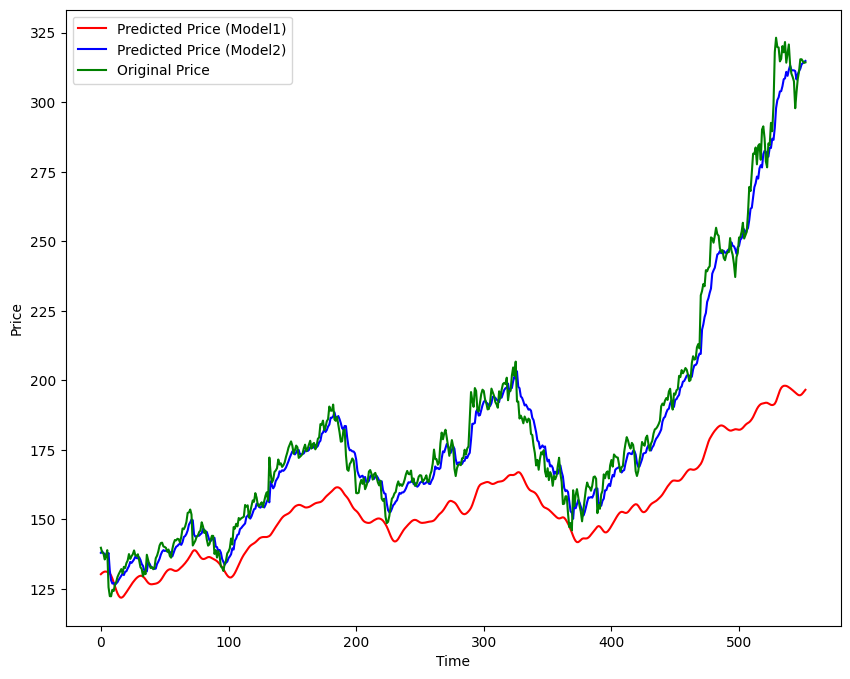

In [50]:
plt.figure(figsize=(10,8))
plt.plot(y_predict1,'r',label='Predicted Price (Model1)')
plt.plot(y_predict2,'b',label='Predicted Price (Model2)')
plt.plot(y,'g',label='Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [51]:
model.save('Stock_Prediction(LSTM).keras')
model1.save('Stock_Prediction(GRU).keras')